# Methods to Access VIIRS data

## Google Earth Engine API
Requirements: 
- Account with Google Eart (free)
- Register Project as non-commercial (free)

In [2]:
# # install if not already
# !pip install earthengine-api

In [1]:
# import libraries
import ee
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# need account + project registered
ee.Authenticate()

True

In [9]:
ee.Initialize()

# Rivian Normal, Illinois factory
lat, lon = 40.5141,  -89.0546

pt = ee.Geometry.Point(lon, lat)
collection = ee.ImageCollection('NASA/VIIRS/002/VNP46A2') \
                .select('Gap_Filled_DNB_BRDF_Corrected_NTL') 

ts = collection.filterDate('2025-07-01', '2025-09-01')

def sample_img(img):
    samp = img.sample(region=pt, scale=500, numPixels=1, dropNulls=False)
    # If no hit, size() == 0; avoid .first().get(...) on null
    val = ee.Algorithms.If(
        samp.size().gt(0),
        ee.Feature(samp.first()).get('Gap_Filled_DNB_BRDF_Corrected_NTL'),
        None
    )
    return ee.Feature(None, {'date': img.date().format('YYYY-MM-dd'), 'radiance': val})


features = ts.map(sample_img).filter(ee.Filter.notNull(['radiance']))
fc = features.getInfo()

dt = []
rad = []
for item in fc['features']:
    dt.append(item['properties']['date'])
    rad.append(item['properties']['radiance'])

df_rivian = pd.DataFrame({
    'date': dt,
    'radiance':rad
})

df_rivian['date'] = pd.to_datetime(df_rivian['date'])

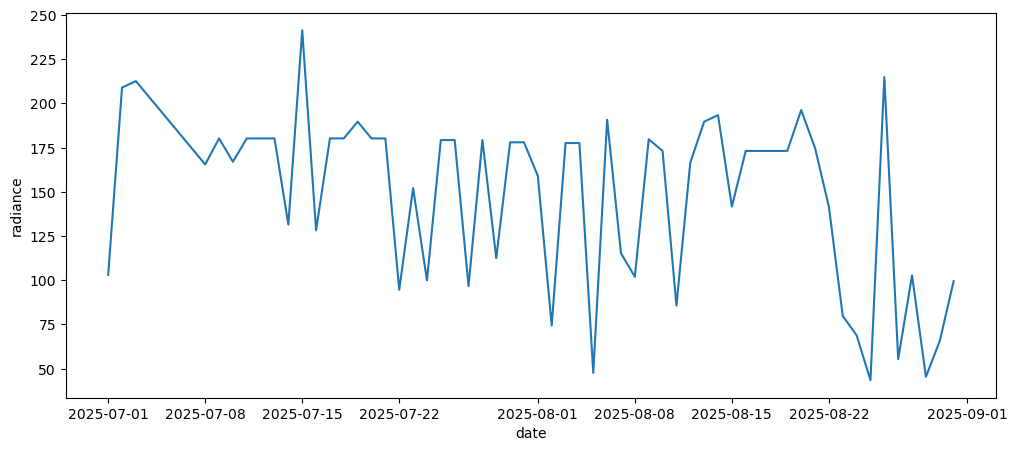

In [15]:
fig = plt.figure(figsize=(12,5))

sns.lineplot(data=df_rivian, x='date',y='radiance')

plt.show()

## Method 2: Use LAADS token
Create an account/token: https://urs.earthdata.nasa.gov/users

In [9]:
# %pip install -q blackmarblepy geopandas shapely pandas
import math
import os, getpass

In [11]:
# You'll see a prompt in the notebook; paste your token and press Enter.
token = getpass.getpass("Paste your LAADS token: ")

# Make it available to BlackMarblePy for THIS session:
os.environ["BLACKMARBLE_TOKEN"] = token

Paste your LAADS token:  ········


In [13]:
def bbox_1km_square_approx(lat, lon):
    """
    Approximate 1 km square; returns (minLon, minLat, maxLon, maxLat).
    Uses standard degree-per-km formulas at the given latitude.
    """
    km_per_deg_lat = 110.574
    km_per_deg_lon = 111.320 * math.cos(math.radians(lat))
    half_km = 0.5

    dlat = half_km / km_per_deg_lat
    dlon = half_km / km_per_deg_lon

    minLon = lon - dlon
    maxLon = lon + dlon
    minLat = lat - dlat
    maxLat = lat + dlat
    return (minLon, minLat, maxLon, maxLat)

In [27]:
def mask_quality_soft(img):
    qf = img.select('QF_Cloud_Mask')
    night = qf.bitwiseAnd(1).eq(0)                        # bit 0: 0 = night
    cloud_ok = qf.rightShift(6).bitwiseAnd(3).lte(2)      # allow clear (0/1) + probably clear (2)
    # Optional: include Mandatory_Quality_Flag < 2 if you want stricter filtering:
    # mqa_ok = img.select('Mandatory_Quality_Flag').lt(2)
    return img.updateMask(night.And(cloud_ok))

# col = (ee.ImageCollection('NASA/VIIRS/002/VNP46A2')
#        .filterDate(start_date, end_date)
#        .map(mask_quality_soft)
#        .select('Gap_Filled_DNB_BRDF_Corrected_NTL'))

def daily_mean(img):
    m = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=500, bestEffort=True, maxPixels=1e8
    )
    return ee.Feature(None, {
        'date': img.date().format('YYYY-MM-dd'),
        'radiance_nWcm2sr': m.get('Gap_Filled_DNB_BRDF_Corrected_NTL')
    })
    
def get_radiance(start_date, end_date, centerLat, centerLon):
    minLon, minLat, maxLon, maxLat = bbox_1km_square_approx(centerLat, centerLon)
    roi = ee.Geometry.Rectangle([minLon, minLat, maxLon, maxLat], geodesic=False)
    col = (ee.ImageCollection('NASA/VIIRS/002/VNP46A2')
           .filterDate(start_date, end_date)
           .map(mask_quality_soft)
           .select('Gap_Filled_DNB_BRDF_Corrected_NTL'))
    
    fc = col.map(daily_mean).filter(ee.Filter.notNull(['radiance_nWcm2sr'])).getInfo()
    data = [(f['properties']['date'], f['properties']['radiance_nWcm2sr']) for f in fc['features']]
    df = pd.DataFrame(data, columns=['date','radiance_nWcm2sr']).sort_values('date')
    df['date'] = pd.to_datetime(df['date'])
    df = df.rename(columns={'radiance_nWcm2sr': 'radiance'})
    return df

In [29]:
# minLon, minLat, maxLon, maxLat = bbox_1km_square_approx()
centerLat, centerLon = 40.5141, -89.0546
start_date, end_date = '2023-01-01', '2025-10-12'
df_rivian = get_radiance(start_date, end_date, centerLat, centerLon)
df_rivian.head()

,date,radiance
0,2023-01-01,35.655800
1,2023-01-04,96.967276
2,2023-01-09,128.798241
3,2023-01-10,98.447848
4,2023-01-17,71.943200


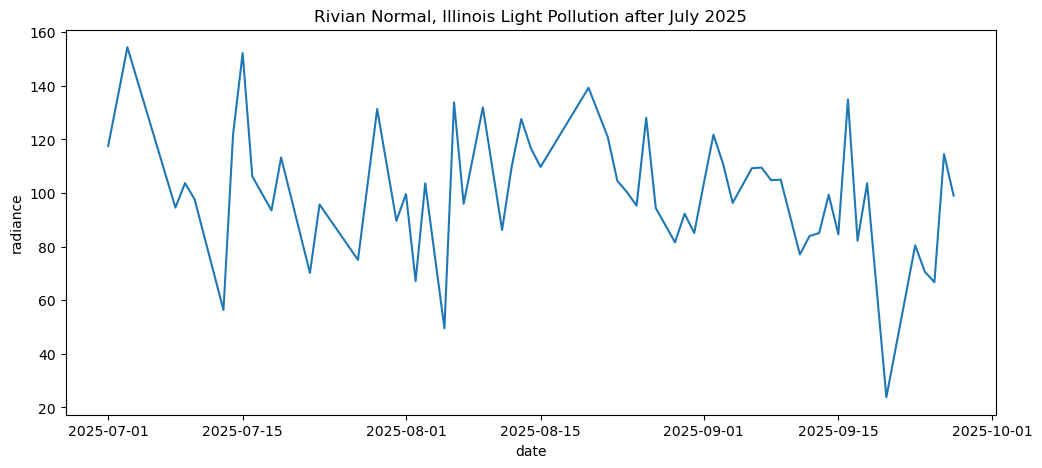

In [35]:
fig = plt.figure(figsize=(12,5))

sns.lineplot(data=df_rivian[df_rivian['date']>='2025-07-01'], 
             x='date',y='radiance')
plt.title('Rivian Normal, Illinois Light Pollution after July 2025')
plt.show()

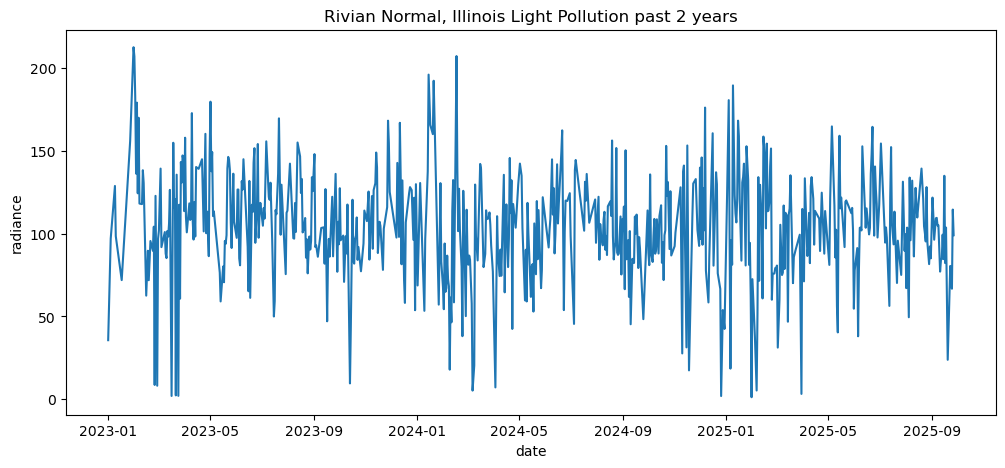

In [37]:
fig = plt.figure(figsize=(12,5))

sns.lineplot(data=df_rivian, x='date',y='radiance')

plt.title('Rivian Normal, Illinois Light Pollution past 2 years')
plt.show()

In [41]:
df_rivian.to_csv('data/rivian_viirs_2yrs.csv')

## GM/BMW factories
Use Below coordinates to get data on other factories:

**GM**
- Arlington Assembly (TX): 32.7383, −97.0736.
- Flint Truck/“Flint Assembly” (MI): 42.98318, −83.71406. 
- Fort Wayne Assembly (IN): 40.9675, −85.3028 (DMS 40°58′03″N 85°18′10″W). 
- Detroit–Hamtramck “Factory ZERO” (MI): 42.3753, −83.0416 (DMS 42°22′31.21″N 83°02′29.58″W)
- Wentzville Assembly (MO): 39.14055, −94.60734
- Fairfax Assembly (KS): 39.1470, −94.6019 (DMS 39°08′49″N 94°36′07″W)
- Lansing Delta Township (MI): 42.7361, −84.5838 (DMS 42°44′10.06″N 84°35′01.70″W)
- Orion Assembly (MI): 42.7172, −83.2620
- Bowling Green Assembly (KY): 37.0114, −86.3656 (DMS 37°00′41″N 86°21′56″W)
- Spring Hill Manufacturing (TN): 35.7371, −86.9579

**BMW**
- flagship plants (lat, lon)
- BMW Plant Spartanburg (Greer, SC, USA): 34.8892, −82.1740
- BMW Plant Munich (Germany): ~48.1797, 11.5594 (BMW HQ/plant complex area)
- BMW Plant Dingolfing (Germany): 
- BMW Plant Regensburg (Germany): 48.9772, 12.1703
- BMW Plant Leipzig (Germany): 51.4081, 12.4435 (Central Building)
- BMW Plant San Luis Potosí (Mexico): 21.96853, −100.84917
- BMW Plant Rosslyn (South Africa): −25.63035, 28.08873 (GPS from BMW directions PDF)
- BMW Brilliance (Shenyang, China – Tiexi/Dadong/Lydia):
